# **Cat-Vs-Dog-Classification**

In [59]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [60]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [ ]:
import os
os.listdir("/kaggle/input/dogsvscats")

['test', 'train', 'catsvsdogs']

In [62]:
!unzip -o <dataset-name>.zip

/bin/bash: line 1: dataset-name: No such file or directory


In [63]:
!kaggle datasets download -d <Jose Luis Cuenca Reyes>/<dogsVScats>

/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `kaggle datasets download -d <Jose Luis Cuenca Reyes>/<dogsVScats>'


In [64]:
import os
os.listdir("/kaggle/input/dogsvscats")

['test', 'train', 'catsvsdogs']

In [65]:
import os
print(os.listdir("/kaggle/input/dogsvscats/train"))
print(os.listdir("/kaggle/input/dogsvscats/test"))

['dogs', 'cats']
['dogs', 'cats']


In [66]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
from keras import regularizers
from keras import initializers
from keras.optimizers import Adam

In [67]:
train_ds = tf.keras.utils.image_dataset_from_directory("/kaggle/input/dogsvscats/train", image_size=(256,256), batch_size=32)
validation_ds = tf.keras.utils.image_dataset_from_directory("/kaggle/input/dogsvscats/test", image_size =(256, 256), batch_size = 32)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [68]:
# Normalize
def process(image, label):
  image =   tf.cast(image/255, tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [69]:
# Creating CNN model

model = Sequential()
model.add(Conv2D(32,kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape = (256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size =(2,2), strides = (2,2), padding = 'valid'))

model.add(Conv2D(64,kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size =(2,2), strides = (2,2), padding = 'valid'))

model.add(Conv2D(90,kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size =(2,2), strides = (2,2), padding = 'valid'))

model.add(Flatten())

model.add(Dense(90, activation = 'relu', kernel_regularizer= regularizers.l2(0.01), kernel_initializer= "he_normal"))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(64, activation = 'relu', kernel_regularizer= regularizers.l2(0.01), kernel_initializer= "he_normal"))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(1, activation = 'sigmoid'))

In [70]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 90)     │        51,930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 60, 60, 90)     │           360 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 90)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 81000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 90)             │     7,290,090 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 90)             │           360 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 90)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,368,661 (28.11 MB)

 Trainable params: 7,367,981 (28.11 MB)

 Non-trainable params: 680 (2.66 KB)

In [71]:
callbacks = EarlyStopping(
    monitor = "val_accuracy",
    patience = 10,
    verbose = 1,
    mode = 'auto',
    restore_best_weights= True,
    min_delta = 0.0001,
    baseline = None,
)

optimizer = Adam(learning_rate = 0.001)

In [72]:
model.compile(loss ='binary_crossentropy', optimizer= optimizer, metrics  = ['accuracy'])

In [73]:
history = model.fit(train_ds, epochs = 30, validation_data = validation_ds, callbacks = callbacks)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.6267 - loss: 2.3696 - val_accuracy: 0.6700 - val_loss: 1.4173
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 90ms/step - accuracy: 0.7184 - loss: 1.2422 - val_accuracy: 0.6982 - val_loss: 1.1577
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7681 - loss: 1.1495 - val_accuracy: 0.7680 - val_loss: 1.0369
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.7915 - loss: 1.2484 - val_accuracy: 0.7380 - val_loss: 1.3333
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8097 - loss: 1.4594 - val_accuracy: 0.7366 - val_loss: 1.6674
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.8217 - loss: 1.5014 - val_accuracy: 0.7246 - val_loss: 1.8726
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.8328 - loss: 1.6822 - val_accuracy: 0.6498 - val_loss: 2.2474
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8456 - loss: 1.7238 - 

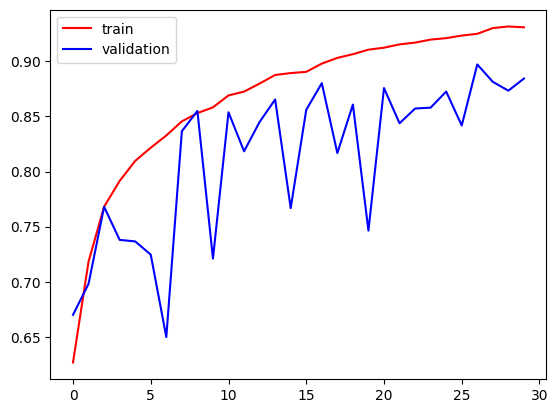

In [74]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color = 'red', label = 'train' )
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

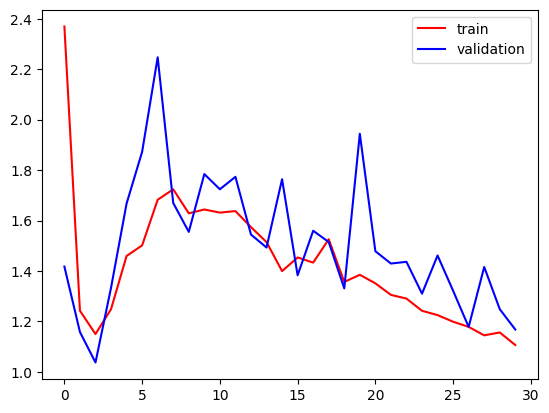

In [75]:
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

In [76]:
import cv2

In [77]:
test_img = cv2.imread("/content/Dog.jpg")

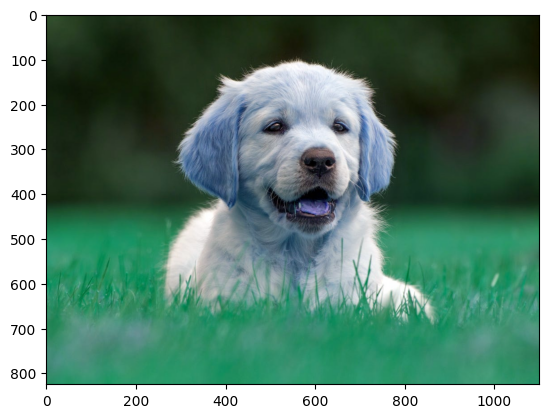

In [78]:

plt.imshow(test_img)

In [79]:
test_img.shape

(825, 1100, 3)

In [80]:
test_img = cv2.resize(test_img, (256,256))

In [81]:
test_input = test_img.reshape((1,256,256,3))


In [82]:
import numpy as np

In [90]:
np.where(model.predict(test_input) > 0.5, "Dog", "Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([['Dog']], dtype='<U3')

In [84]:
test_img2 = cv2.imread("/content/Cat.jpg")

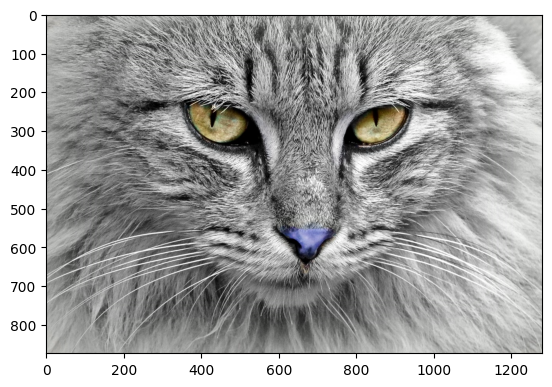

In [85]:
plt.imshow(test_img2)

In [86]:
test_img2 = cv2.resize(test_img2,(256,256))
test_input2 = test_img2.reshape((1,256,256,3))

In [91]:
np.where(model.predict(test_input2) >0.5, "Dog","Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([['Cat']], dtype='<U3')

In [94]:
model.save("DogVsCatClassifier.keras")

In [95]:
!zip -r DogVsCatClassifier.zip DogVsCatClassifier

	zip warning: name not matched: DogVsCatClassifier

zip error: Nothing to do! (try: zip -r DogVsCatClassifier.zip . -i DogVsCatClassifier)
